<a href="https://colab.research.google.com/github/SyedaMalaika75/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

**Lane:** Ranking Signal Analysis  
**Action supported:** refresh/content review prioritization

This notebook reuses the same leakage-safe grouped-validation design used in the Week-5 modeling work and the Week-6 validation audit.

## 1. Question

**Research question:**  
Which public-safe page-level content and search-performance signals are useful for ranking pages associated with observed search-visibility decline, and can a leakage-safe Logistic Regression improve review prioritization over a simple rule baseline?

**Decision supported:** prioritize which pages a content/SEO team should manually review first.

This is decision-support, not a guarantee of future decline and not proof that refreshing a page causes ranking improvement.

In [1]:
research_question = ("Which public-safe page-level content and search-performance signals are useful "
                     "for ranking pages associated with observed search-visibility decline, and can a "
                     "leakage-safe Logistic Regression improve review prioritization over a rule baseline?")
lane = "Ranking Signal Analysis"
decision_supported = "Prioritize pages for manual refresh/content review"
print("Research question:", research_question)
print("Lane:", lane)
print("Decision supported:", decision_supported)

Research question: Which public-safe page-level content and search-performance signals are useful for ranking pages associated with observed search-visibility decline, and can a leakage-safe Logistic Regression improve review prioritization over a rule baseline?
Lane: Ranking Signal Analysis
Decision supported: Prioritize pages for manual refresh/content review


## 2. Data

I use the anonymized FlyRank internship content-refresh dataset already used in my earlier track notebooks.

- Unit of analysis: one content page
- Outcome label: `trend_direction == "down"` → observed decline label
- Validation: 80/20 grouped split by `client_id`
- Public-safe reporting only
- Excluded from public reporting: client names, domains, URLs, private queries, raw exports

In [2]:
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import GroupShuffleSplit

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "SyedaMalaika75/flyrank-ml-internship/"
    "main/data/raw/content_refresh_anonymized.csv"
)

df = pd.read_csv(DATA_URL)
df["decline_label"] = (df["trend_direction"] == "down").astype(int)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_index, test_index = next(
    splitter.split(df, y=df["decline_label"], groups=df["client_id"])
)
train_df = df.iloc[train_index].copy()
test_df = df.iloc[test_index].copy()

train_clients = set(train_df["client_id"])
test_clients = set(test_df["client_id"])

print("Rows:", len(df))
print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print("Training clients:", train_df["client_id"].nunique())
print("Testing clients:", test_df["client_id"].nunique())
print("Clients appearing in both:", len(train_clients & test_clients))
print("Test base rate:", round(test_df["decline_label"].mean(), 3))
assert len(train_clients & test_clients) == 0

Rows: 30000
Training rows: 23837
Testing rows: 6163
Training clients: 25
Testing clients: 7
Clients appearing in both: 0
Test base rate: 0.511


## 3. Methodology

I use Logistic Regression as a ranking/scoring model. The predicted probability is used to order pages from higher to lower review priority.

The model uses safe content metadata and trailing 90-day performance features. I exclude IDs, provider/model names, outcome-derived fields, and recent trend-window columns.

The rule baseline prioritizes:
1. stale but visible pages,
2. visible pages with low CTR,
3. impressions as a tie-breaker.

Both the baseline and model are evaluated on the **same held-out clients** using Precision@20 and Precision@50.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

train_model_df = train_df.copy()
test_model_df = test_df.copy()

for frame in [train_model_df, test_model_df]:
    frame["avg_position_missing"] = (frame["avg_position"] == 0).astype(int)
    frame.loc[frame["avg_position"] == 0, "avg_position"] = np.nan

numeric_features = [
    "search_volume","competition","cpc","word_count","char_count",
    "content_age_days","days_since_last_update","impressions_90d","clicks_90d",
    "pageviews_90d","sessions_90d","users_90d","engaged_sessions_90d",
    "ai_sessions_90d","scroll_events_90d","days_with_impressions",
    "days_with_sessions","ctr","avg_position","avg_position_missing",
    "engagement_rate","scroll_rate","ai_traffic_pct"
]

categorical_features = [
    "competition_level","content_type","main_intent","age_tier",
    "freshness_tier","word_count_tier","char_count_tier",
    "impression_tier","position_tier"
]

feature_columns = numeric_features + categorical_features

banned_features = {
    "content_id","client_id","provider_used","model_used",
    "trend_direction","trend_pct",
    "impressions_last_30d","clicks_last_30d","sessions_last_30d",
    "impressions_prev_30d","clicks_prev_30d","sessions_prev_30d"
}

leaked_features = sorted(set(feature_columns) & banned_features)
print("Leaked features detected:", leaked_features)
assert not leaked_features

X_train = train_model_df[feature_columns]
y_train = train_model_df["decline_label"]
X_test = test_model_df[feature_columns]
y_test = test_model_df["decline_label"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

model_pipeline.fit(X_train, y_train)
model_scores = model_pipeline.predict_proba(X_test)[:, 1]

# Week-4 rule baseline on the same test set
baseline_ranked = test_model_df.copy()
baseline_ranked["signal_stale_visible"] = (
    (baseline_ranked["days_since_last_update"] >= 180) &
    (baseline_ranked["impressions_90d"] >= 500)
)
baseline_ranked["signal_low_ctr_visible"] = (
    (baseline_ranked["impressions_90d"] >= 500) &
    (baseline_ranked["avg_position"].between(1, 20)) &
    (baseline_ranked["ctr"] < 0.5)
)
baseline_ranked["volume_tiebreak"] = np.minimum(
    baseline_ranked["impressions_90d"] / 5000, 1.0
) * 10
baseline_ranked["baseline_score"] = (
    baseline_ranked["signal_stale_visible"].astype(int) * 100 +
    baseline_ranked["signal_low_ctr_visible"].astype(int) * 60 +
    baseline_ranked["volume_tiebreak"]
)
baseline_ranked = baseline_ranked.sort_values(
    ["baseline_score","impressions_90d"], ascending=[False,False]
).reset_index(drop=True)

model_ranked = test_model_df[
    ["decline_label","impressions_90d","days_since_last_update","ctr","avg_position"]
].copy()
model_ranked["model_score"] = model_scores
model_ranked = model_ranked.sort_values(
    ["model_score","impressions_90d"], ascending=[False,False]
).reset_index(drop=True)

def precision_at_k(frame, k):
    return frame.head(k)["decline_label"].mean()

test_base_rate = y_test.mean()
baseline_p20 = precision_at_k(baseline_ranked, 20)
baseline_p50 = precision_at_k(baseline_ranked, 50)
model_p20 = precision_at_k(model_ranked, 20)
model_p50 = precision_at_k(model_ranked, 50)

print("Features used:", len(feature_columns))
print("Model trained successfully.")

Leaked features detected: []
Features used: 32
Model trained successfully.


## 4. Results (vs baseline)

The learned model is compared with the Week-4 rule baseline on the same grouped holdout.

The key interpretation is ranking quality: among the first pages a reviewer would inspect, how many are observed decline cases?

In [4]:
comparison_table = pd.DataFrame({
    "Approach": ["Week 4 rule baseline", "Logistic Regression"],
    "Test base rate": [test_base_rate, test_base_rate],
    "Precision@20": [baseline_p20, model_p20],
    "Precision@50": [baseline_p50, model_p50]
})
display(comparison_table.round(3))

top50 = model_ranked.head(50)
print("Top-50 correct decline cases:", int(top50["decline_label"].sum()), "/50")
print("Top-50 false positives:", int((top50["decline_label"] == 0).sum()))

,Approach,Test base rate,Precision@20,Precision@50
0,Week 4 rule baseline,0.511,0.4,0.42
1,Logistic Regression,0.511,0.7,0.72


Top-50 correct decline cases: 36 /50
Top-50 false positives: 14


## 5. Limitations

This work cannot claim that the model knows Google's ranking algorithm, that a high score guarantees future decline, or that refreshing a page causes rankings to improve.

The model measures patterns associated with observed decline in this anonymized dataset. False positives and missed decline cases remain. The output should therefore be used as **directional decision-support** and combined with human review.

In [5]:
false_positives = int((top50["decline_label"] == 0).sum())
correct_top50 = int(top50["decline_label"].sum())
print("Observed correct cases in top 50:", correct_top50)
print("False positives in top 50:", false_positives)
print("Safe interpretation: directional decision-support, not causal proof or a guarantee.")

Observed correct cases in top 50: 36
False positives in top 50: 14
Safe interpretation: directional decision-support, not causal proof or a guarantee.


## 6. Ranked recommendations

Action playbook:

1. Review the highest-scored pages first.
2. Prioritize pages with enough visibility to make review operationally meaningful.
3. Use stale-content and low-CTR signals as transparent reasons for investigation.
4. Require human confirmation before making content changes.
5. Monitor outcomes after any refresh or intervention.

In [6]:
recommendations = model_ranked.head(10).copy()
recommendations.insert(0, "review_rank", range(1, len(recommendations) + 1))
recommendations["recommended_action"] = "Manual review first"
display(recommendations[
    ["review_rank","model_score","impressions_90d",
     "days_since_last_update","ctr","avg_position","recommended_action"]
].round(3))

,review_rank,model_score,impressions_90d,days_since_last_update,ctr,avg_position,recommended_action
0,1,0.929,128,20,0.00,4.2,Manual review first
1,2,0.922,138,8,0.00,14.6,Manual review first
2,3,0.916,157,20,0.00,6.1,Manual review first
3,4,0.906,556,20,0.00,14.3,Manual review first
4,5,0.901,235,20,0.85,31.0,Manual review first
5,6,0.896,140079,20,0.01,7.6,Manual review first
6,7,0.894,3115,104,0.00,12.8,Manual review first
7,8,0.893,290,20,0.00,5.9,Manual review first
8,9,0.888,68,20,0.00,3.0,Manual review first
9,10,0.885,149,20,0.00,4.3,Manual review first


## 7. Artifacts the paper embeds

The deployed paper uses:
- the model-vs-baseline result table,
- a Precision@20 / Precision@50 comparison chart,
- the top-ranked public-safe review table.

No client names, domains, URLs, or private queries are included.

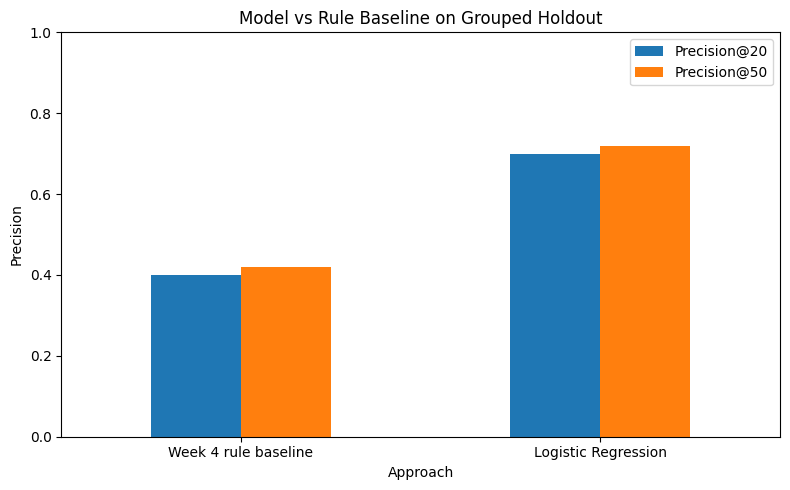

In [7]:
import matplotlib.pyplot as plt

chart_df = comparison_table.set_index("Approach")[["Precision@20","Precision@50"]]
ax = chart_df.plot(kind="bar", figsize=(8,5))
ax.set_ylim(0,1)
ax.set_ylabel("Precision")
ax.set_title("Model vs Rule Baseline on Grouped Holdout")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## ML-12 — Demo and sharing cuts

### 5-minute demo outline
1. Problem: too many pages to review manually.
2. Data: anonymized FlyRank page-level data and grouped client split.
3. Method: rule baseline vs leakage-safe Logistic Regression.
4. Result: Precision@20 0.40 → 0.70 and Precision@50 0.42 → 0.72.
5. Limitations: directional decision-support, not causal proof.
6. Action: use the ranking to decide which pages receive human review first.

### Social-post cut
I completed a FlyRank ML capstone on ranking content pages for review priority. Using a client-grouped holdout and leakage-safe Logistic Regression, the learned ranking improved Precision@50 from 0.42 for a simple rule baseline to 0.72. The result is framed as decision-support: it helps prioritize review, not guarantee future decline.

### 3-sentence employer-facing summary
I built and validated a Logistic Regression ranking model on anonymized search/content data. I used client-grouped validation, leakage checks, a transparent rule baseline, and error analysis to keep the evaluation honest. The model improved Precision@50 from 0.42 to 0.72 and produces a ranked queue for human content review.

## Self-check

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/`
- [ ] My deployed paper has all required sections including Abstract and Acknowledgments & data credit
- [ ] ML-12 demo outline + social-post cut + employer-facing summary are included
